In [1]:
import numpy as np
import pandas as pd 
from pathlib import Path

import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="dark")

from sklearn.metrics import r2_score
from scipy.stats import spearmanr

In [2]:
# Load predictions

output_path = Path('/marbec-data/RLS-Australia/malpolon/outputs/')
pred_path = output_path / '24_humenv_cat_reg_top100-2025-09-15_16-04-preds' / 'predictions.csv'
predictions = pd.read_csv(pred_path, index_col='survey_id')
predictions = np.exp(predictions) - 1

predictions_tb = predictions.sum(axis=1)
predictions_sr = (predictions > 0).sum(axis=1)
predictions_prev = (predictions > 0).sum(axis=0)

In [3]:
# Load targets

p = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_split.csv')
df = pd.read_csv(p, index_col='survey_id',
                      usecols = ['survey_id', 'subset'] + list(predictions.columns))
targets = df.loc[df['subset'] == 'test', predictions.columns]

# Test dataset summary
targets_tb = targets.sum(axis=1)
targets_sr = (targets > 0).sum(axis=1)
targets_pres = (targets > 0).astype(int)
targets_prev = (targets > 0).sum(axis=0)

## Calculate R2 by species

In [4]:
r2s = {}
spr = {}

for s in predictions.columns:
    groundtruth = targets[s]
    preds = predictions[s]

    r2s[s] = r2_score(np.log(1+groundtruth), np.log(1+preds))
    spr[s] = spearmanr(groundtruth, preds)[0]


r2s = pd.Series(r2s)
sprs = pd.Series(spr)

In [5]:
df = pd.concat([targets_prev, r2s, sprs], axis = 1)
df.columns = ['occurrences', 'r2', 'spr']
df['species'] = df.index
df.sort_values('spr', ascending=False)


,occurrences,r2,spr,species
Notolabrus parilus,639,0.838299,0.922214,Notolabrus parilus
Pomacentrus moluccensis,459,0.452007,0.736568,Pomacentrus moluccensis
Notolabrus tetricus,2330,0.585298,0.719563,Notolabrus tetricus
Ctenochaetus striatus,367,0.416104,0.680439,Ctenochaetus striatus
Halichoeres melanurus,301,0.440611,0.674596,Halichoeres melanurus
...,...,...,...,...
Olisthops cyanomelas,1459,-0.920429,0.122575,Olisthops cyanomelas
Chromis nitida,116,-0.130329,0.102468,Chromis nitida
Pictilabrus laticlavius,1589,-0.832904,0.079103,Pictilabrus laticlavius
Cheilinus chlorourus,191,-0.120894,0.065748,Cheilinus chlorourus


In [6]:
fig = px.scatter(df, x="occurrences", y="r2", hover_data = "species")
fig.show()

## Display best species predictions

<Axes: xlabel='Notolabrus parilus', ylabel='Notolabrus parilus'>

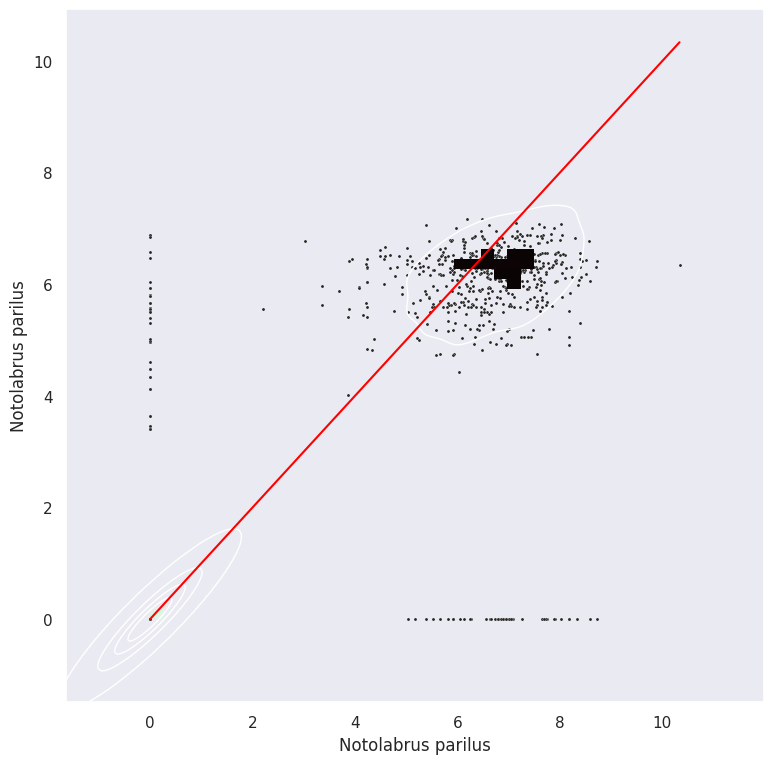

In [12]:
s = 'Notolabrus parilus'

x, y = np.log(1+targets[s]), np.log(1+predictions[s])

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')

## Species richness

<Axes: xlabel='None', ylabel='None'>

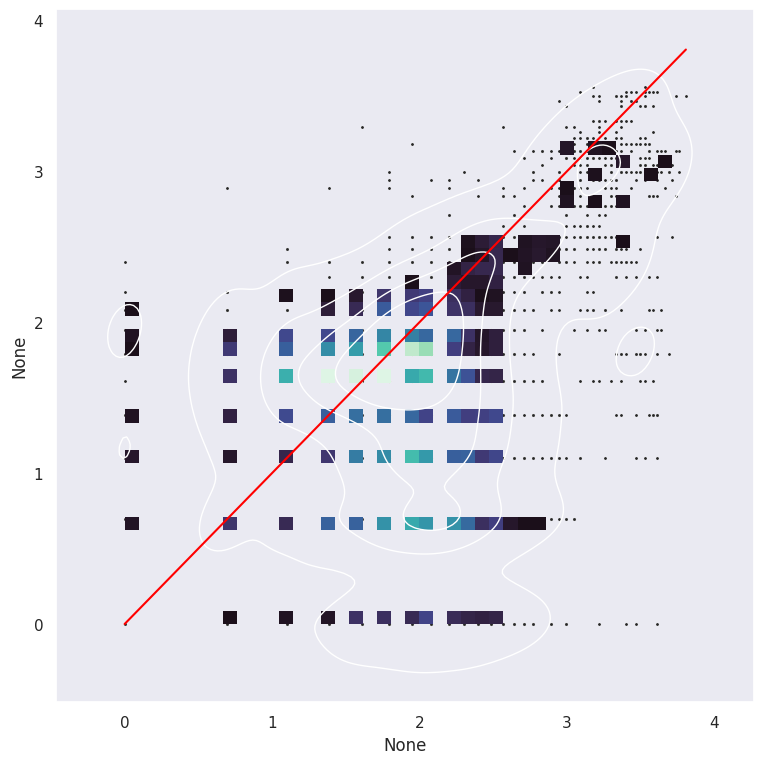

In [9]:
x, y = np.log(1+targets_sr), np.log(1+predictions_sr)

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')